In [1]:
#!pip install -q https://github.com/aifimmunology/multicelltypist/archive/main.zip

In [ ]:
# imporint
import celltypist
from celltypist import models

In [ ]:
#set directory
cd ./analysis/celltypist_mapping

In [ ]:
pwd

# extract top markers for future reference

In [ ]:
models.models_path
#/path/to/celltypist/models/

In [5]:
# model information
models.models_description(on_the_fly = True)["model"]

👉 Detailed model information can be found at `https://www.celltypist.org/models`


0                             Healthy_COVID19_PBMC.pkl
1                                  Immune_All_High.pkl
2                                   Immune_All_Low.pkl
3    ref_pbmc_clean_celltypist_model_AIFI_L1_2024-0...
4    ref_pbmc_clean_celltypist_model_AIFI_L3_2024-0...
5    ref_pbmc_clean_celltypist_model_AIFI_L2_2024-0...
Name: model, dtype: object

In [43]:
#Select the model from the above list. If the `model` argument is not provided, will default to `Immune_All_Low.pkl`.
model = models.Model.load(model = 'ref_pbmc_clean_celltypist_model_AIFI_L1_2024-04-18.pkl')
model = models.Model.load(model = 'ref_pbmc_clean_celltypist_model_AIFI_L2_2024-04-19.pkl')
model = models.Model.load(model = 'ref_pbmc_clean_celltypist_model_AIFI_L3_2024-04-19.pkl')

In [44]:
#The model summary information.
model

CellTypist model with 29 cell types and 1936 features
    date: 2024-04-19 01:10:18.286351
    cell types: ASDC, CD14 monocyte, ..., pDC
    features: HES4, ISG15, ..., MT-CYB

In [45]:
#Examine cell types contained in the model.
model.cell_types

array(['ASDC', 'CD14 monocyte', 'CD16 monocyte', 'CD56bright NK cell',
       'CD56dim NK cell', 'CD8aa', 'DN T cell', 'Effector B cell',
       'Erythrocyte', 'ILC', 'Intermediate monocyte', 'MAIT',
       'Memory B cell', 'Memory CD4 T cell', 'Memory CD8 T cell',
       'Naive B cell', 'Naive CD4 T cell', 'Naive CD8 T cell',
       'Plasma cell', 'Platelet', 'Progenitor cell',
       'Proliferating NK cell', 'Proliferating T cell',
       'Transitional B cell', 'Treg', 'cDC1', 'cDC2', 'gdT', 'pDC'],
      dtype=object)

In [46]:
#Examine genes/features contained in the model.
model.features

array(['HES4', 'ISG15', 'TTLL10', ..., 'MT-ND3', 'MT-ND4', 'MT-CYB'],
      dtype=object)

In [50]:
model.extract_top_markers('Treg', top_n = 20)

array(['FOXP3', 'RTKN2', 'FANK1', 'ENTPD1', 'IKZF2', 'FCER1G', 'NCF4',
       'S100A4', 'HACD1', 'IL2RA', 'METTL7A', 'IL32', 'TNFRSF1B', 'STAM',
       'FCRL3', 'TIGIT', 'HLA-DRB1', 'VAV3', 'AC133644.2', 'LGALS3'],
      dtype=object)

In [48]:
marker_dict = {}
celltypes = model.cell_types
for ct in celltypes:
    top_markers = model.extract_top_markers(cell_type = ct, top_n = 20)
    marker_dict[ct] = top_markers
marker_dict

{'ASDC': array(['AXL', 'PLS3', 'SCT', 'SIGLEC6', 'HAMP', 'BICC1', 'KCNK10',
        'HTR3A', 'CLEC4C', 'AC090409.1', 'PF4V1', 'IGKV3-20', 'RGS16',
        'CDH1', 'LILRA4', 'SELENBP1', 'SYT2', 'TNFRSF11A', 'ALAS2', 'BMP3'],
       dtype=object),
 'CD14 monocyte': array(['CCL4', 'CTSS', 'FTL', 'CCL3', 'LYZ', 'TYROBP', 'ANXA1', 'S100A12',
        'FOSB', 'VCAN', 'FCN1', 'IDO1', 'GAPDH', 'MNDA', 'S100A11', 'EGR3',
        'CD83', 'RGS2', 'PPP1R15A', 'MS4A6A'], dtype=object),
 'CD16 monocyte': array(['C1QC', 'C1QB', 'FCGR3A', 'CDKN1C', 'RHOC', 'LST1', 'CX3CR1',
        'RPS19', 'CD79B', 'TXNIP', 'AP002852.1', 'FCER1A', 'PECAM1',
        'TTLL10', 'MALAT1', 'DNTT', 'IFITM3', 'SPN', 'DRD4', 'IGHGP'],
       dtype=object),
 'CD56bright NK cell': array(['GZMK', 'COTL1', 'CAPG', 'KLRD1', 'CD2', 'IL7R', 'GPR183', 'GNLY',
        'BMP3', 'SELL', 'CTSW', 'ITGAX', 'IGFBP4', 'AP002852.1', 'MIXL1',
        'AC104699.1', 'NKG7', 'HAMP', 'KIRREL3', 'IFITM3'], dtype=object),
 'CD56dim NK cell': array(['

In [49]:
import pandas as pd 
marker_df = pd.DataFrame.from_dict(marker_dict)
marker_df = marker_df.T
marker_df.to_csv("./analysis/celltypist_mapping/AIFI_L2_Top20_MarkerList.csv")

# Load Adata Obj

In [21]:
import scanpy as sc
adata_tnk = sc.read_h5ad("/mnt/isilon/tan_lab/wanga14/Lymphoma_CART/analysis/seurat_objects/all_samples_TNKonly.h5ad")
adata_mono = sc.read_h5ad("/mnt/isilon/tan_lab/wanga14/Lymphoma_CART/analysis/seurat_objects/all_samples_MONOonly.h5ad")

In [22]:
adata_tnk.obs = adata_tnk.obs[[ 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 
                       'percent.mt', 'percent.ribo', 'barcode', 'raw_clonotype_id', 
                       'chain', 'v_gene', 'j_gene', 'd_gene', 'c_gene', 'productive', 
                       'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'HeatShock.Score1', 
                        'Doublet_Singlet', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 
                       'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 
                       'predicted.celltype.l3', 'sample.name','patient.id', 'response', 'str_split', 
                       'timepoint', 'timepoint_order','harmony.snn_res.0.6', 'harmony.snn_res.0.8', 
                       'harmony.snn_res.1', 'harmony.snn_res.1.5', 'harmony.snn_res.2', 'harmony.snn_res.0.2',
                       'harmony.snn_res.0.4', 'harmonyumap_1', 'harmonyumap_2', 
                       'basic.anno', 'int.snn_res.0.6', 'int.snn_res.0.8', 
                       'int.snn_res.1', 'int.snn_res.1.5', 'int.snn_res.2']]

adata_tnk.var = adata_tnk.var[['var.features', 'var.features.rank']]

In [7]:
adata_mono.obs = adata_mono.obs[[ 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 
                       'percent.mt', 'percent.ribo', 'barcode', 'raw_clonotype_id', 
                       'chain', 'v_gene', 'j_gene', 'd_gene', 'c_gene', 'productive', 
                       'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'HeatShock.Score1', 
                        'Doublet_Singlet', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 
                       'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 
                       'predicted.celltype.l3', 'sample.name','patient.id', 'response', 'str_split', 
                       'timepoint', 'timepoint_order','harmony.snn_res.0.6', 'harmony.snn_res.0.8', 
                       'harmony.snn_res.1', 'harmony.snn_res.1.5', 'harmony.snn_res.2', 'harmony.snn_res.0.2',
                       'harmony.snn_res.0.4', 'harmonyumap_1', 'harmonyumap_2', 
                       'basic.anno', 'int.snn_res.0.6', 'int.snn_res.0.8', 
                       'int.snn_res.1', 'int.snn_res.1.5', 'int.snn_res.2']]

adata_mono.var = adata_mono.var[['var.features', 'var.features.rank']]

# try AIFI models via Celltypist 

In [30]:
model_names = ['Healthy_COVID19_PBMC.pkl','Immune_All_Low.pkl', 
               'ref_pbmc_clean_celltypist_model_AIFI_L1_2024-04-18.pkl',
               'ref_pbmc_clean_celltypist_model_AIFI_L2_2024-04-19.pkl',
               'ref_pbmc_clean_celltypist_model_AIFI_L3_2024-04-19.pkl']
model_names_short = ["Healthy_COVID19_PBMC", "Celltypist_Immune_Atlas", "AIFI_L1", "AIFI_L2", "AIFI_L3"]

In [11]:
#Select the model from the above list. If the `model` argument is not provided, will default to `Immune_All_Low.pkl`.
model = models.Model.load(model = 'ref_pbmc_clean_celltypist_model_AIFI_L2_2024-04-19.pkl')
#The model summary information.
model
#Examine cell types contained in the model.
model.cell_types
#Examine genes/features contained in the model.
model.features

array(['HES4', 'ISG15', 'TTLL10', ..., 'MT-ND3', 'MT-ND4', 'MT-CYB'],
      dtype=object)

In [24]:
# for TNK sample 

label_results = {}
predictions_results = {}

for i in range(len(model_names)):
    name = model_names[i]
    model_name = model_names_short[i]
    model = models.Model.load(model = name)
    label_column = f'{model_name}_prediction'
    score_column = f'{model_name}_score'
    
    predictions = celltypist.annotate(
        adata_tnk, 
        model = name,
        majority_voting = True, 
    )
    
    labels = predictions.predicted_labels
    labels = labels.rename({'predicted_labels': label_column}, axis = 1)
    predictions_results[model_name] = predictions

    prob = predictions.probability_matrix
    prob_scores = []
    for i in range(labels.shape[0]):
        prob_scores.append(prob.loc[labels.index.to_list()[i],labels[label_column][i]])
    labels[score_column] = prob_scores

    label_results[model_name] = labels

🔬 Input data has 237291 cells and 25398 genes
🔗 Matching reference genes in the model
🧬 1913 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 30
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 237291 cells and 25398 genes
🔗 Matching reference genes in the model
🧬 2474 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 30
🗳️ Majority voting the predictions
✅ Majority voting done!


In [15]:
for model_name, label_df in label_results.items():    
    label_column = f'{model_name}_prediction'
    label_summary = label_df[label_column].value_counts()
    print(label_summary[0:10], end = '\n\n')

Healthy_COVID19_PBMC_prediction
CD4.Naive     38528
CD8.TE        28911
CD4.Prolif    27344
CD8.EM        18404
NK_16hi       15048
NK_prolif     14963
CD8.Prolif    14048
CD4.IL22      13837
CD4.EM        12897
CD8.Naive     12826
Name: count, dtype: int64

Celltypist_Immune_Atlas_prediction
Regulatory T cells                       45817
Tem/Temra cytotoxic T cells              43290
Tem/Effector helper T cells              34379
Tcm/Naive helper T cells                 28860
Tem/Trm cytotoxic T cells                28044
CD16+ NK cells                           14766
Plasmablasts                             14472
Proliferative germinal center B cells    12138
Tcm/Naive cytotoxic T cells               5193
NK cells                                  1919
Name: count, dtype: int64

AIFI_L1_prediction
T cell             219668
NK cell             16830
Monocyte              659
DC                     76
ILC                    24
Progenitor cell        17
B cell                 13
Platelet

In [24]:
#save predictions

for model_name, label_df in label_results.items():
    label_df.to_csv( model_name + "_TNK_celltypist_majvote_predictions.csv")

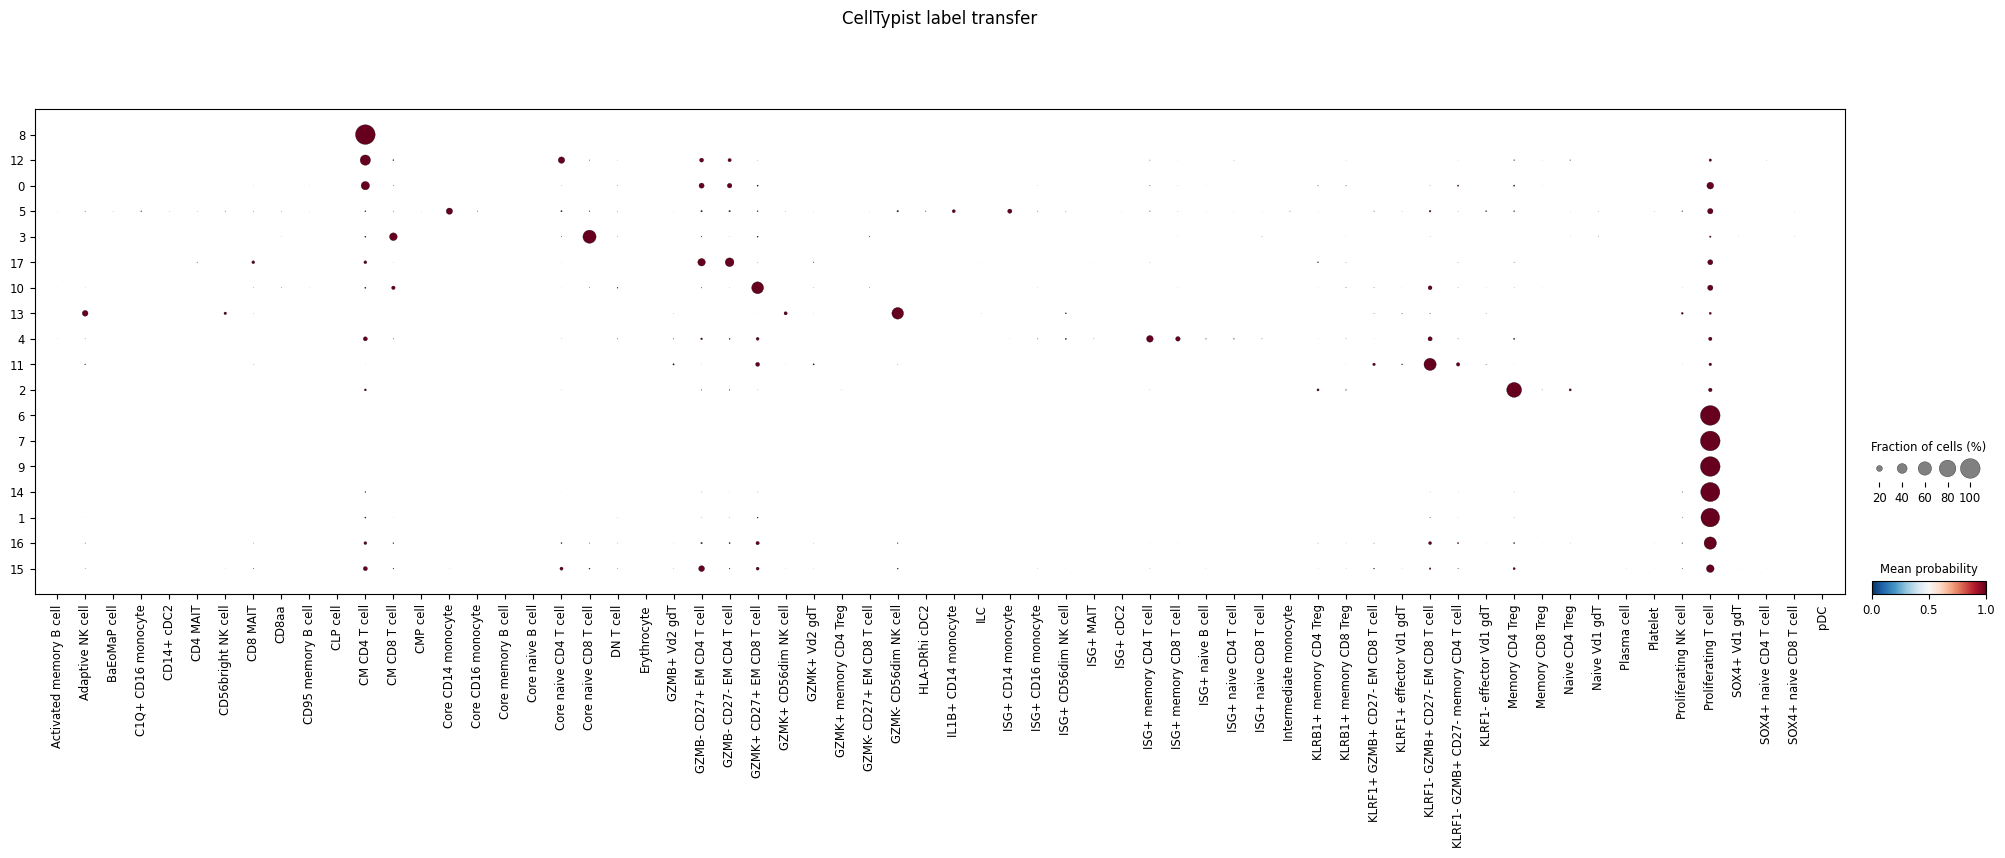

In [30]:
# visualize 
celltypist.dotplot(predictions_results["AIFI_L3"]
                   , use_as_reference = 'int.snn_res.0.6', use_as_prediction = 'predicted_labels',swap_axes = True,
                  save = "TNK_AIFI_L3_dotplot_RPCAres0.6.png")

# run for Monocyte susbet 

In [10]:
# run for Mono
label_results_mono = {}
predictions_mono = {}

for i in range(len(model_names)):
    name = model_names[i]
    model_name = model_names_short[i]
    model = models.Model.load(model = name)
    label_column = f'{model_name}_prediction'
    score_column = f'{model_name}_score'
    
    predictions = celltypist.annotate(
        adata_mono, 
        model = name,
        majority_voting = True
    )
    
    labels = predictions.predicted_labels
    labels = labels.rename({'predicted_labels': label_column}, axis = 1)

    prob = predictions.probability_matrix
    prob_scores = []
    for i in range(labels.shape[0]):
        prob_scores.append(prob.loc[labels.index.to_list()[i],labels[label_column][i]])
    labels[score_column] = prob_scores

    label_results_mono[model_name] = labels
    predictions_mono[model_name] = predictions

🔬 Input data has 139069 cells and 25398 genes
🔗 Matching reference genes in the model
🧬 1913 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
2024-11-18 14:28:52.833491: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /cm/shared/easybuild/software/Python/3.10.4-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/OpenSSL/1.1/lib:/cm/shared/easybuild/software/libffi/3.4.2-GCCcore-11.3.0/lib64:/cm/shared/easybuild/software/GMP/6.2.1-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/XZ/5.2.5-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/SQLite/3.38.3-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/Tcl/8.6.12-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/libreadline/8.1.2-GCCcore-11.3.0/lib:/cm

In [32]:
#save
for model_name, label_df in label_results_mono.items():
    label_df.to_csv( model_name + "_MONO_celltypist_majvote_predictions.csv")

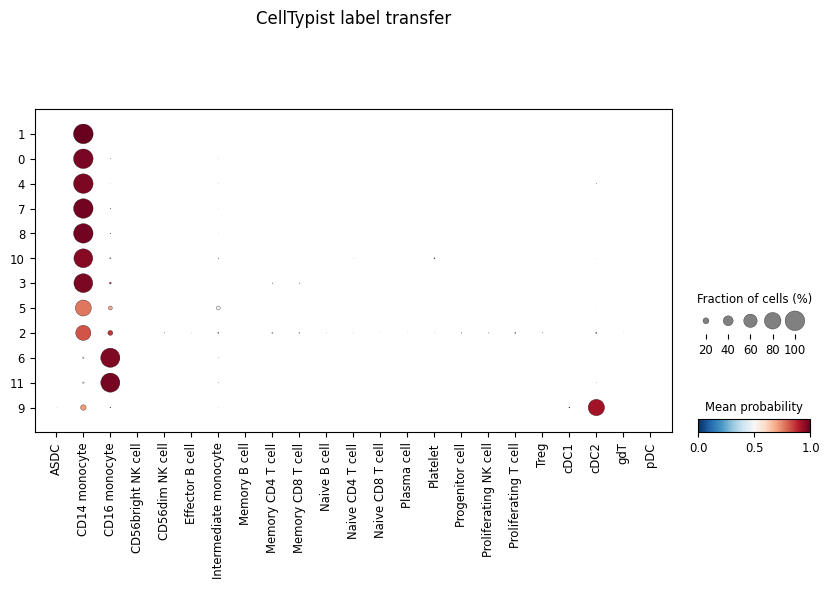

In [19]:
import matplotlib.pyplot as plt
celltypist.dotplot(predictions_mono["AIFI_L2"]
                   , use_as_reference = 'int.snn_res.0.6', use_as_prediction = 'predicted_labels',swap_axes = True,
                  save = "Mono_AIFI_L2_dotplot_RPCAres0.6.png")
